# Module 10 — Aggregation & Counting Analysis

**Research Question**: Can LLMs accurately count and aggregate game statistics (total actions, cumulative payoffs)?

**Checks**: Count of each action type per agent, total accumulated payoff per agent — tested at rounds 10, 20, 30.

**Key Finding Preview**: This is the **weakest cognitive ability** (~19% accuracy overall), revealing fundamental limitations in LLM numerical reasoning during interactive games.

**Outputs**: Figure 10a (aggregation accuracy heatmap), Figure 10b (question-type breakdown), Figure 10c (error magnitude analysis), Figure 10d (accuracy vs. round progression), Figure 10e (by language)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from itertools import combinations
import re
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality settings ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False,
})

# ── Color palette (color-blind friendly) ──
MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
MODEL_ORDER = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
NOISE_LABELS = {0: 'No Noise', 5: '5% Noise', 20: '20% Noise'}
NOISE_ORDER = ['No Noise', '5% Noise', '20% Noise']
LANG_LABELS = {'en': 'English', 'fr': 'French', 'ar': 'Arabic',
               'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}
LANG_ORDER = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data from individual JSON files ──
import json, glob

BASE_DIR = '../resources/results/Prisoner_dilemma_2player'
NOISE_MAP = {'noise00': 0, 'noise05': 5, 'noise20': 20}

records = []

for model_dir in sorted(os.listdir(BASE_DIR)):
    model_path = os.path.join(BASE_DIR, model_dir)
    if not os.path.isdir(model_path):
        continue
    llm_name = model_dir.split('_vs30round_')[0]
    
    for noise_dir in sorted(os.listdir(model_path)):
        noise_path = os.path.join(model_path, noise_dir)
        if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
            continue
        noise_level = NOISE_MAP[noise_dir]
        
        # ── Read summary JSONs for sample_mean (accuracy) per question ──
        checker_path = os.path.join(noise_path, 'aggregation_checker')
        if not os.path.exists(checker_path):
            continue
        
        # ── Read complete_answers for per-round individual answers ──
        ca_path = os.path.join(checker_path, 'complete_answers')
        for ca_file in sorted(os.listdir(ca_path)):
            if not ca_file.endswith('.json'):
                continue
            
            # Also read metadata from the summary JSON
            summary_file = ca_file.replace('complete_answers_', 'aggregation_checker_')
            summary_path = os.path.join(checker_path, summary_file)
            
            with open(summary_path, 'r', encoding='utf-8') as fh:
                summary = json.load(fh)
            meta = summary['metadata']
            game_id = meta['game_id']
            language = meta['language']
            p1_personality = meta['agents']['agent1']['personality']
            p2_personality = meta['agents']['agent2']['personality']
            
            with open(os.path.join(ca_path, ca_file), 'r', encoding='utf-8') as fh:
                answers = json.load(fh)
            
            # Each key in answers is a question_label
            for question_label, rounds_data in answers.items():
                for round_idx, round_info in rounds_data.items():
                    ans = round_info['answer']
                    records.append({
                        'game_id': game_id,
                        'llm_name': llm_name,
                        'noise_level': noise_level,
                        'language': language,
                        'p1_personality': p1_personality,
                        'p2_personality': p2_personality,
                        'question_label': question_label,
                        'question_text': round_info['question'],
                        'agent_name': ans['agent_name'],
                        'round_number': ans['round_number'],
                        'llm_answer': ans['llm_answer'],
                        'correct_answer': ans['correct_answer'],
                        'is_correct': ans['is_correct'],
                    })

df = pd.DataFrame(records)
print(f'Loaded {len(df):,} rows from JSON files')
print(f'Models: {sorted(df["llm_name"].unique())}')
print(f'Languages: {sorted(df["language"].unique())}')
print(f'Noise levels: {sorted(df["noise_level"].unique())}')

# ── Add derived columns ──
df['model'] = df['llm_name'].map(MODEL_LABELS)
df['noise_label'] = df['noise_level'].map(NOISE_LABELS)
df['lang_label'] = df['language'].map(LANG_LABELS)

# ── Classify question types ──
def classify_agg_question(label):
    if label.startswith('total_payoff'):
        return 'Total Payoff'
    elif label.startswith('#actions'):
        return 'Action Count'
    else:
        return 'Other'

df['question_type'] = df['question_label'].apply(classify_agg_question)

# ── Extract agent perspective (self vs opponent) ──
def get_agg_perspective(row):
    ql = row['question_label']
    an = row['agent_name']
    match = re.search(r'agent([12])', ql)
    if match:
        q_agent = f'agent{match.group(1)}'
        return 'Self' if q_agent == an else 'Opponent'
    return 'Unknown'

df['perspective'] = df.apply(get_agg_perspective, axis=1)

# ── Compute numerical error magnitude ──
def safe_numeric(val):
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

df['llm_answer_num'] = df['llm_answer'].apply(safe_numeric)
df['correct_answer_num'] = df['correct_answer'].apply(safe_numeric)
df['abs_error'] = (df['llm_answer_num'] - df['correct_answer_num']).abs()
df['rel_error'] = df['abs_error'] / df['correct_answer_num'].abs().replace(0, np.nan)

print(f'\nQuestion types: {df["question_type"].value_counts().to_dict()}')
print(f'Overall aggregation accuracy: {df["is_correct"].mean():.3f}')
print(f'Median absolute error: {df["abs_error"].median():.1f}')

Loaded 77,760 rows from JSON files
Models: ['Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct', 'gpt-oss-20b']
Languages: ['ar', 'cn', 'en', 'fr', 'it', 'vn']
Noise levels: [np.int64(0), np.int64(5), np.int64(20)]

Question types: {'Action Count': 51840, 'Total Payoff': 25920}
Overall aggregation accuracy: 0.162
Median absolute error: 5.0


## Figure 10a — Aggregation Accuracy Heatmap (Model × Noise)

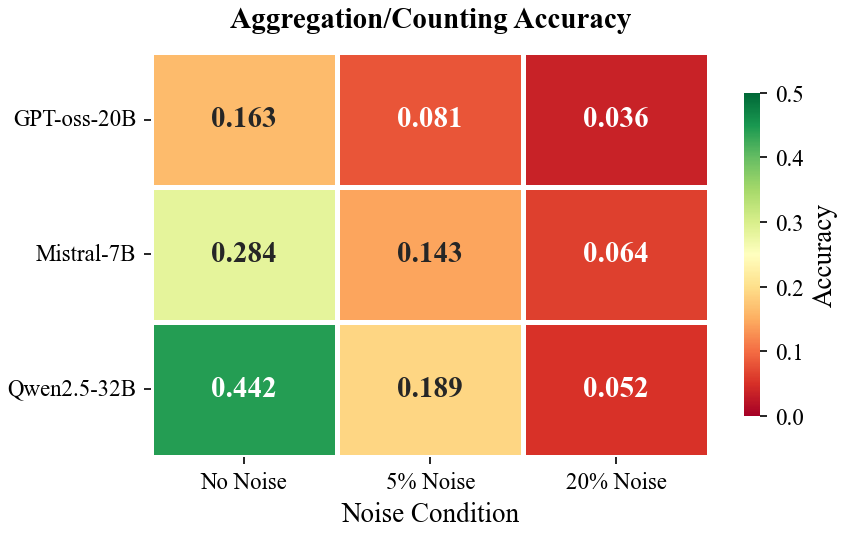


Accuracy table:
noise_label  No Noise  5% Noise  20% Noise
model                                     
GPT-oss-20B     0.163     0.081      0.036
Mistral-7B      0.284     0.143      0.064
Qwen2.5-32B     0.442     0.189      0.052


In [3]:
# ── Figure 10a: Heatmap of aggregation accuracy by Model × Noise ──
pivot = df.groupby(['model', 'noise_label'])['is_correct'].mean().unstack()
pivot = pivot.reindex(index=MODEL_ORDER, columns=NOISE_ORDER)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.0, vmax=0.5,
            linewidths=1.5, linecolor='white', cbar_kws={'label': 'Accuracy', 'shrink': 0.8},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Aggregation/Counting Accuracy', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Noise Condition', fontsize=13)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.savefig(f'{FIGURE_DIR}fig10a_aggregation_accuracy_heatmap.pdf')
plt.savefig(f'{FIGURE_DIR}fig10a_aggregation_accuracy_heatmap.png')
plt.show()
print('\nAccuracy table:')
print(pivot.round(3))

## Figure 10b — Action Count vs. Total Payoff Accuracy

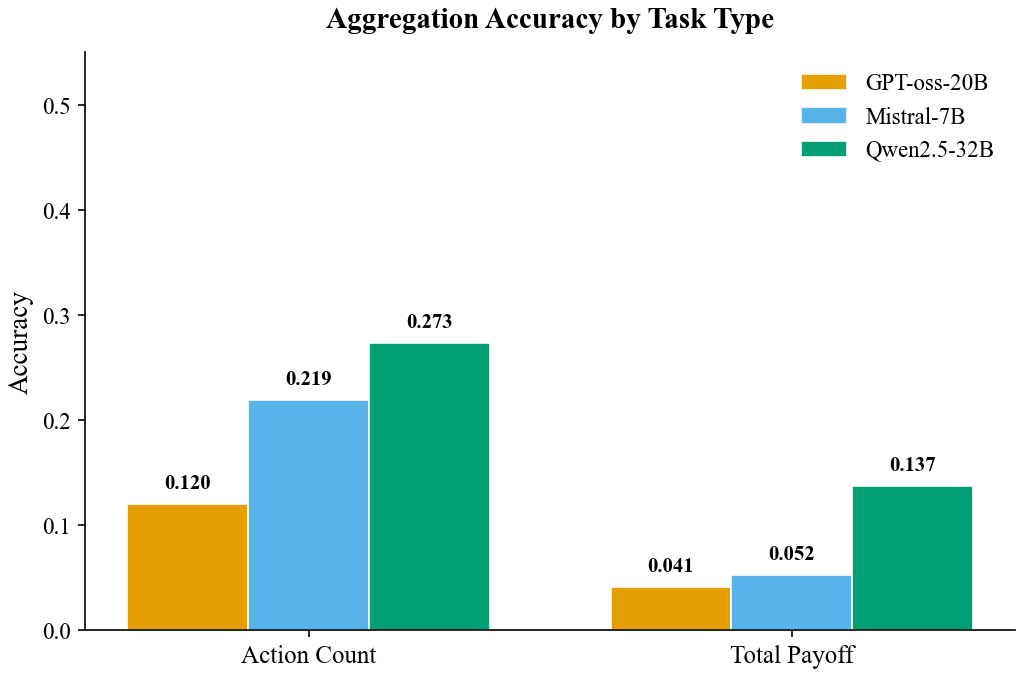


Accuracy by aggregation type:
question_type  Action Count  Total Payoff
model                                    
GPT-oss-20B           0.120         0.041
Mistral-7B            0.219         0.052
Qwen2.5-32B           0.273         0.137


In [4]:
# ── Figure 10b: Grouped bar — Action Count vs Total Payoff by model ──
agg_types = ['Action Count', 'Total Payoff']
at_acc = df.groupby(['model', 'question_type'])['is_correct'].mean().unstack()
at_acc = at_acc.reindex(index=MODEL_ORDER, columns=agg_types)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(agg_types))
width = 0.25
colors_list = [MODEL_COLORS[k] for k in ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']]

for i, model in enumerate(MODEL_ORDER):
    vals = at_acc.loc[model].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=colors_list[i],
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Aggregation Accuracy by Task Type', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(agg_types, fontsize=12)
ax.set_ylim(0, 0.55)
ax.legend(frameon=False, loc='upper right')

plt.savefig(f'{FIGURE_DIR}fig10b_aggregation_type_breakdown.pdf')
plt.savefig(f'{FIGURE_DIR}fig10b_aggregation_type_breakdown.png')
plt.show()

print('\nAccuracy by aggregation type:')
print(at_acc.round(3))

## Figure 10c — Error Magnitude Distribution

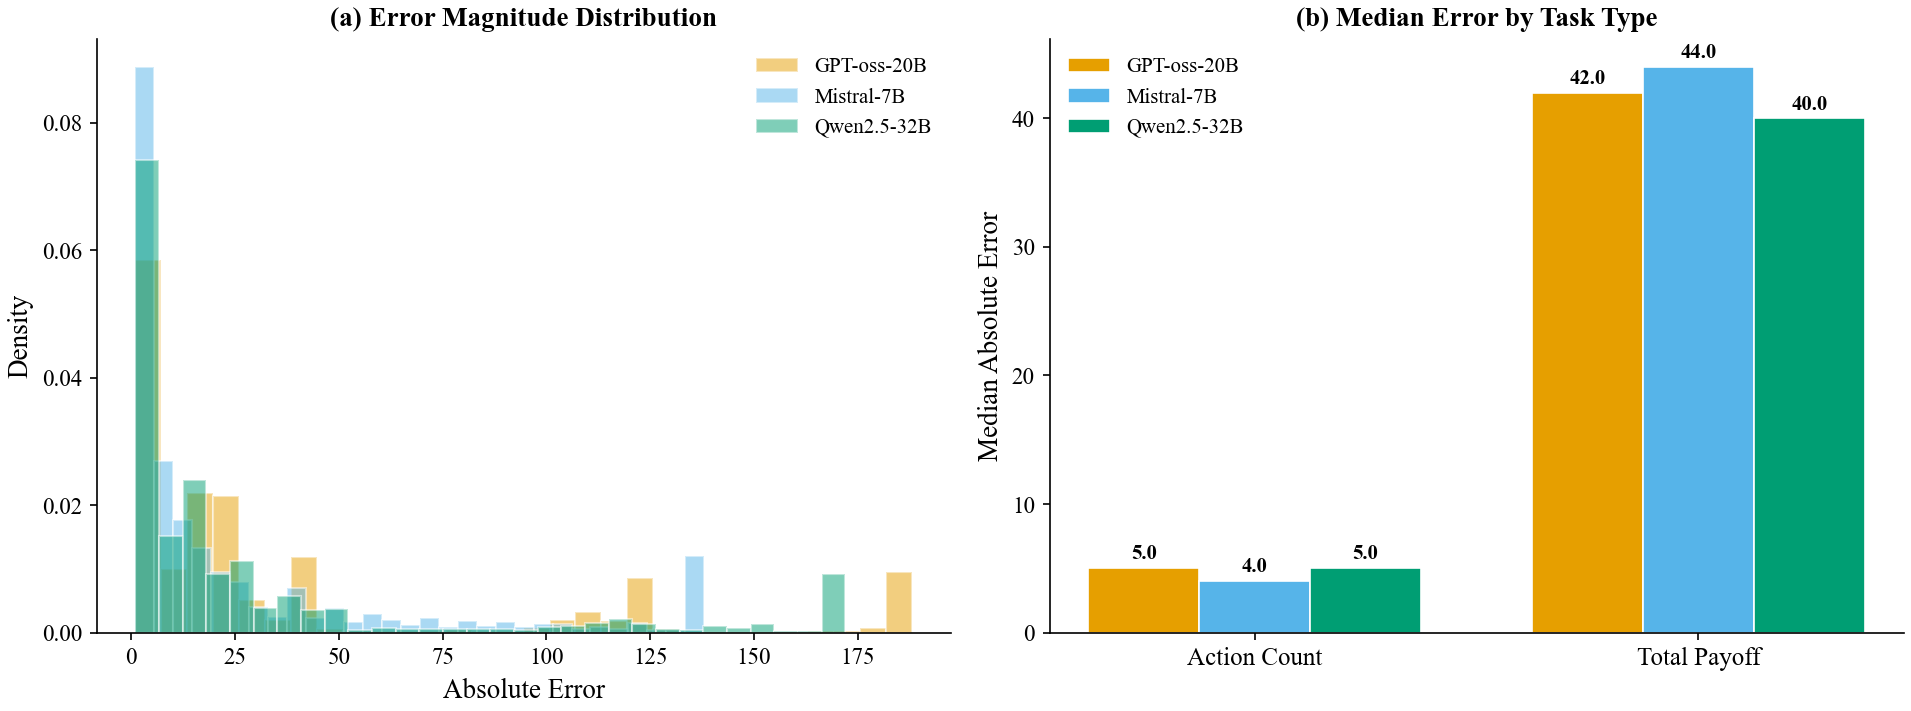


Median absolute error by model × type:
question_type  Action Count  Total Payoff
model                                    
GPT-oss-20B             5.0          42.0
Mistral-7B              4.0          44.0
Qwen2.5-32B             5.0          40.0


In [5]:
# ── Figure 10c: Error magnitude analysis ──
# Focus on incorrect answers with valid numerics
errors = df[(~df['is_correct']) & df['abs_error'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Absolute error distribution by model
ax = axes[0]
for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    sub = errors[errors['llm_name'] == mkey]
    # Clip extreme values for visualization
    err_clipped = sub['abs_error'].clip(upper=sub['abs_error'].quantile(0.95))
    ax.hist(err_clipped, bins=30, alpha=0.5, label=mname, color=MODEL_COLORS[mkey],
            edgecolor='white', density=True)

ax.set_xlabel('Absolute Error', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('(a) Error Magnitude Distribution', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)

# Panel B: Median error by question type and model
ax = axes[1]
med_err = errors.groupby(['model', 'question_type'])['abs_error'].median().unstack()
med_err = med_err.reindex(index=MODEL_ORDER, columns=agg_types)

x = np.arange(len(agg_types))
width = 0.25
for i, model in enumerate(MODEL_ORDER):
    vals = med_err.loc[model].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=colors_list[i],
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Median Absolute Error', fontsize=13)
ax.set_title('(b) Median Error by Task Type', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(agg_types, fontsize=12)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig10c_error_magnitude.pdf')
plt.savefig(f'{FIGURE_DIR}fig10c_error_magnitude.png')
plt.show()

print('\nMedian absolute error by model × type:')
print(med_err.round(1))

## Figure 10d — Aggregation Accuracy Over Rounds (Gets Harder?)

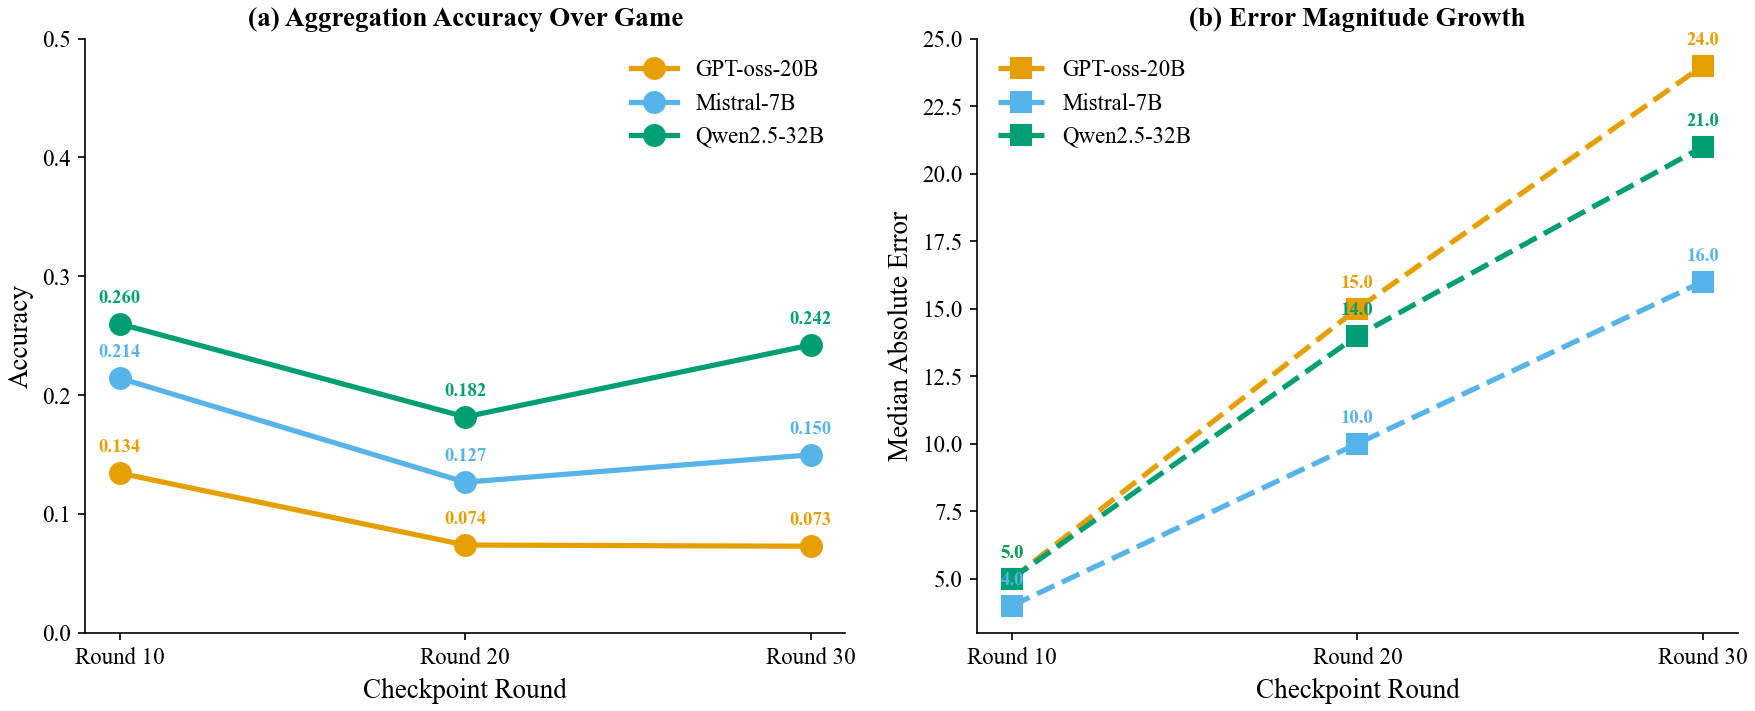

In [6]:
# ── Figure 10d: Does aggregation accuracy decrease as the game progresses? ──
# More rounds = bigger numbers to count → harder task
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Overall accuracy by checkpoint
ax = axes[0]
for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    cp_acc = sub.groupby('round_number')['is_correct'].mean()
    ax.plot(cp_acc.index, cp_acc.values, 'o-', color=MODEL_COLORS[mkey],
            label=mname, markersize=10, linewidth=2.5)
    for r, v in cp_acc.items():
        ax.annotate(f'{v:.3f}', xy=(r, v), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=9,
                    fontweight='bold', color=MODEL_COLORS[mkey])

ax.set_xlabel('Checkpoint Round', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('(a) Aggregation Accuracy Over Game', fontsize=13, fontweight='bold')
ax.set_xticks([10, 20, 30])
ax.set_xticklabels(['Round 10', 'Round 20', 'Round 30'])
ax.legend(frameon=False)
ax.set_ylim(0, 0.5)

# Panel B: Median error growth
ax = axes[1]
for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    sub = errors[errors['llm_name'] == mkey]
    cp_err = sub.groupby('round_number')['abs_error'].median()
    ax.plot(cp_err.index, cp_err.values, 's--', color=MODEL_COLORS[mkey],
            label=mname, markersize=10, linewidth=2.5)
    for r, v in cp_err.items():
        ax.annotate(f'{v:.1f}', xy=(r, v), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=9,
                    fontweight='bold', color=MODEL_COLORS[mkey])

ax.set_xlabel('Checkpoint Round', fontsize=13)
ax.set_ylabel('Median Absolute Error', fontsize=13)
ax.set_title('(b) Error Magnitude Growth', fontsize=13, fontweight='bold')
ax.set_xticks([10, 20, 30])
ax.set_xticklabels(['Round 10', 'Round 20', 'Round 30'])
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig10d_aggregation_over_rounds.pdf')
plt.savefig(f'{FIGURE_DIR}fig10d_aggregation_over_rounds.png')
plt.show()

## Figure 10e — Aggregation Accuracy by Language

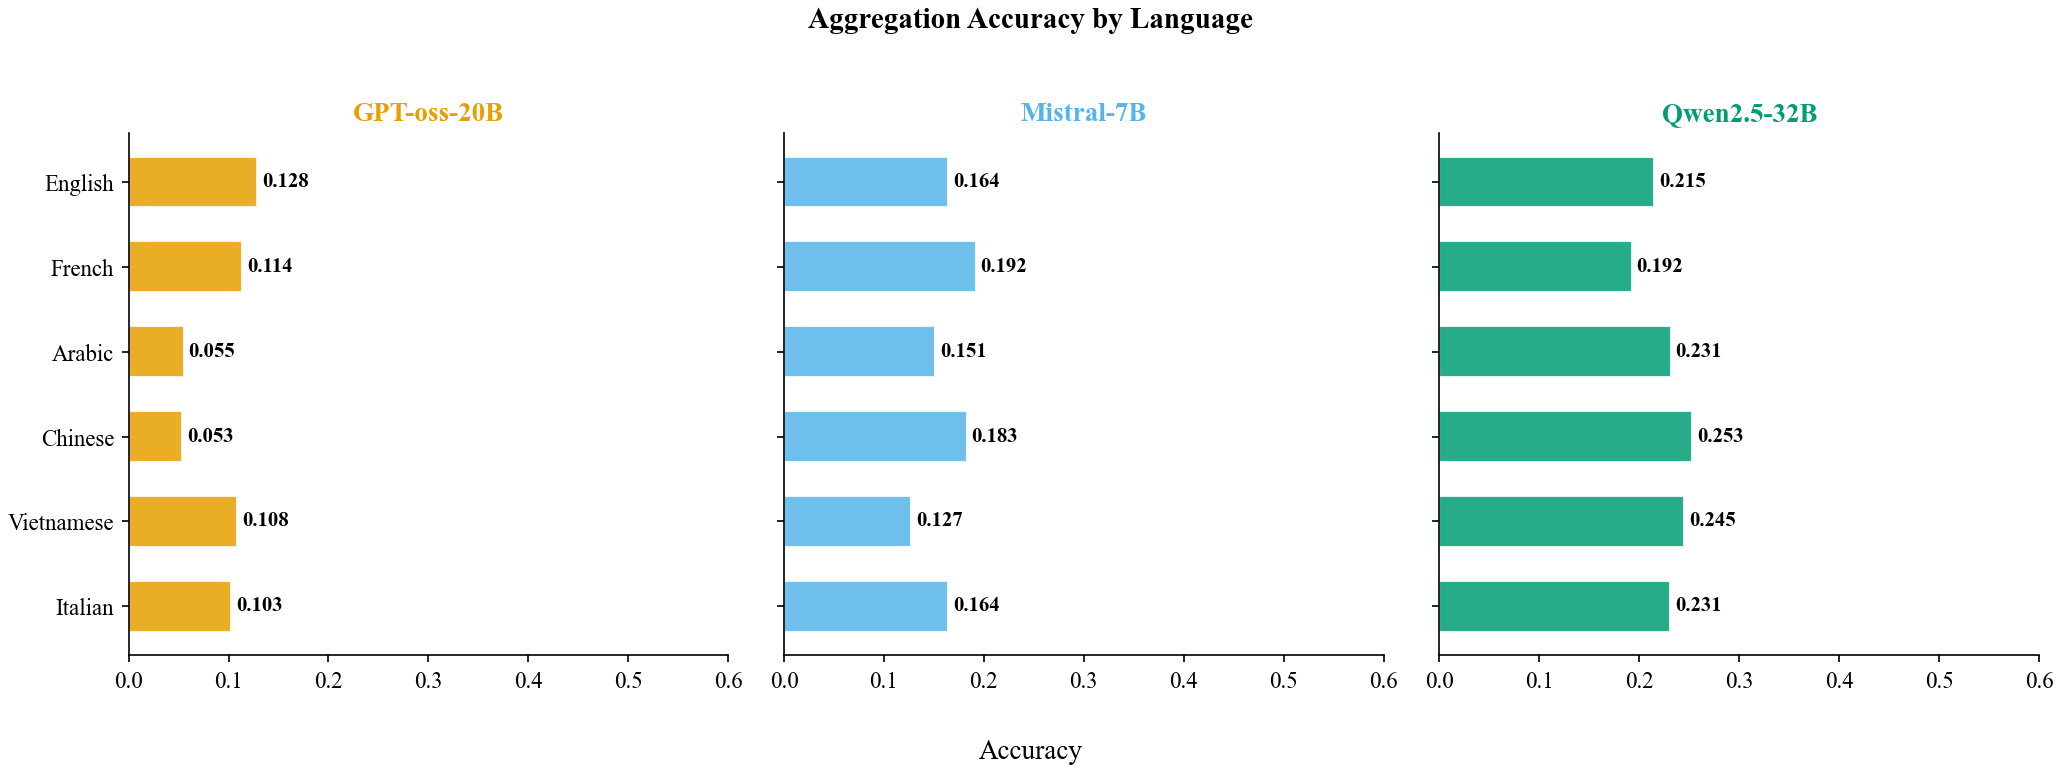

In [7]:
# ── Figure 10e: Aggregation accuracy by language ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

model_keys = ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']

for idx, (mkey, mname) in enumerate(zip(model_keys, MODEL_ORDER)):
    ax = axes[idx]
    sub = df[df['llm_name'] == mkey]
    lang_acc = sub.groupby('lang_label')['is_correct'].mean().reindex(LANG_ORDER)
    
    bars = ax.barh(LANG_ORDER, lang_acc.values, color=MODEL_COLORS[mkey],
                   edgecolor='white', height=0.6, alpha=0.85)
    
    for bar, val in zip(bars, lang_acc.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_title(mname, fontsize=13, fontweight='bold', color=MODEL_COLORS[mkey])
    ax.set_xlim(0, 0.6)
    ax.invert_yaxis()

fig.suptitle('Aggregation Accuracy by Language', fontsize=14, fontweight='bold', y=1.02)
fig.supxlabel('Accuracy', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig10e_aggregation_by_language.pdf')
plt.savefig(f'{FIGURE_DIR}fig10e_aggregation_by_language.png')
plt.show()

## Figure 10f — Self vs. Opponent Counting Accuracy

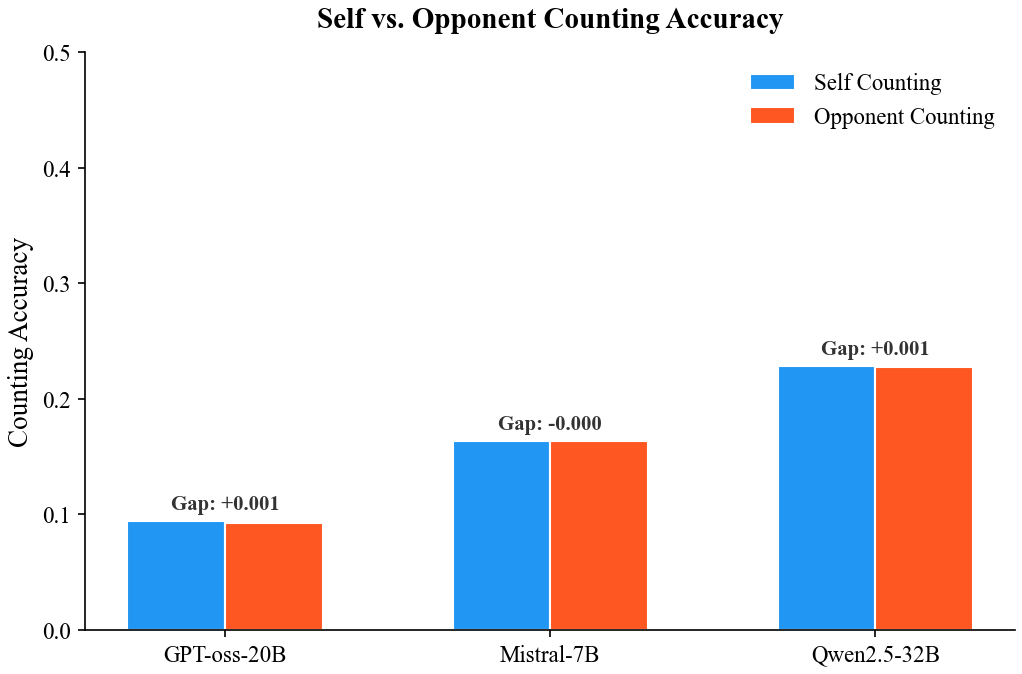

In [8]:
# ── Figure 10f: Self vs Opponent aggregation accuracy ──
persp_df = df[df['perspective'].isin(['Self', 'Opponent'])].copy()

fig, ax = plt.subplots(figsize=(8, 5))

persp_model = persp_df.groupby(['model', 'perspective'])['is_correct'].mean().unstack()
persp_model = persp_model.reindex(MODEL_ORDER)

x = np.arange(len(MODEL_ORDER))
width = 0.3
ax.bar(x - width/2, persp_model['Self'], width, label='Self Counting',
       color='#2196F3', edgecolor='white')
ax.bar(x + width/2, persp_model['Opponent'], width, label='Opponent Counting',
       color='#FF5722', edgecolor='white')

for i, model in enumerate(MODEL_ORDER):
    s_val = persp_model.loc[model, 'Self']
    o_val = persp_model.loc[model, 'Opponent']
    gap = s_val - o_val
    ax.annotate(f'Gap: {gap:+.3f}', xy=(i, max(s_val, o_val) + 0.01),
                ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel('Counting Accuracy', fontsize=13)
ax.set_title('Self vs. Opponent Counting Accuracy', fontsize=14, fontweight='bold', pad=12)
ax.legend(frameon=False)
ax.set_ylim(0, 0.5)

plt.savefig(f'{FIGURE_DIR}fig10f_self_vs_opponent_counting.pdf')
plt.savefig(f'{FIGURE_DIR}fig10f_self_vs_opponent_counting.png')
plt.show()

## Figure 10g — Cognitive Ability Comparison (Rule vs Time vs Aggregation)

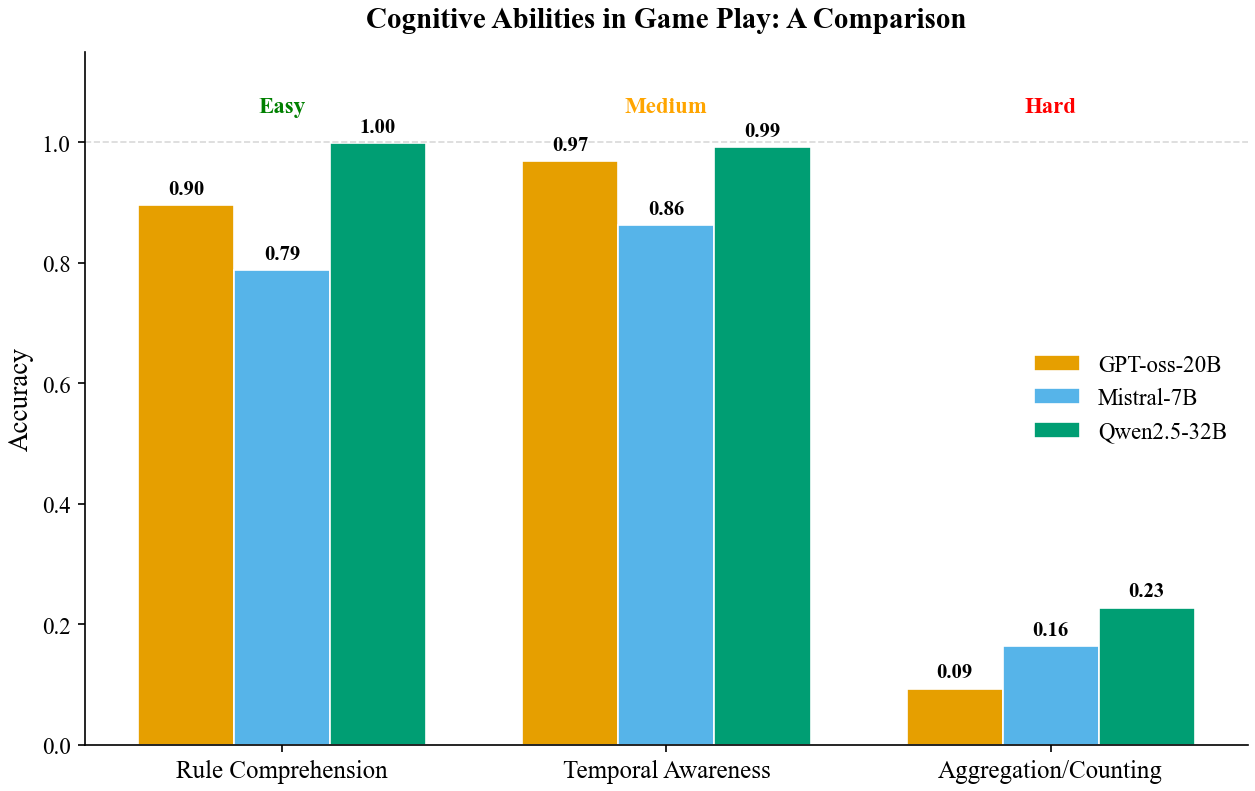

In [9]:
# ── Figure 10g: Grand comparison across all 3 checker types ──
# Load rule_checker and time_checker data from JSON files as well
def load_checker_from_json(checker_name):
    """Load a checker's complete_answers from all model/noise directories."""
    recs = []
    for model_dir in sorted(os.listdir(BASE_DIR)):
        model_path = os.path.join(BASE_DIR, model_dir)
        if not os.path.isdir(model_path):
            continue
        llm = model_dir.split('_vs30round_')[0]
        for noise_dir in sorted(os.listdir(model_path)):
            noise_path = os.path.join(model_path, noise_dir)
            if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
                continue
            ca_path = os.path.join(noise_path, checker_name, 'complete_answers')
            if not os.path.exists(ca_path):
                continue
            for ca_file in sorted(os.listdir(ca_path)):
                if not ca_file.endswith('.json'):
                    continue
                with open(os.path.join(ca_path, ca_file), 'r', encoding='utf-8') as fh:
                    answers = json.load(fh)
                for ql, rounds_data in answers.items():
                    for ri, rinfo in rounds_data.items():
                        ans = rinfo['answer']
                        recs.append({'llm_name': llm, 'is_correct': ans['is_correct']})
    return pd.DataFrame(recs)

rc_df = load_checker_from_json('rule_checker')
tc_df = load_checker_from_json('time_checker')

fig, ax = plt.subplots(figsize=(10, 6))

checker_types = ['Rule Comprehension', 'Temporal Awareness', 'Aggregation/Counting']

acc_data = []
for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    rc_acc = rc_df[rc_df['llm_name'] == mkey]['is_correct'].mean()
    tc_acc = tc_df[tc_df['llm_name'] == mkey]['is_correct'].mean()
    ac_acc = df[df['llm_name'] == mkey]['is_correct'].mean()
    acc_data.append([rc_acc, tc_acc, ac_acc])

x = np.arange(len(checker_types))
width = 0.25
colors_list = [MODEL_COLORS[k] for k in ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']]

for i, (model, vals) in enumerate(zip(MODEL_ORDER, acc_data)):
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=colors_list[i],
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Cognitive Abilities in Game Play: A Comparison', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(checker_types, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(frameon=False, fontsize=11)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

# Add difficulty annotation
ax.annotate('Easy', xy=(0, 1.05), ha='center', fontsize=11, color='green', fontweight='bold')
ax.annotate('Medium', xy=(1, 1.05), ha='center', fontsize=11, color='orange', fontweight='bold')
ax.annotate('Hard', xy=(2, 1.05), ha='center', fontsize=11, color='red', fontweight='bold')

plt.savefig(f'{FIGURE_DIR}fig10g_cognitive_ability_comparison.pdf')
plt.savefig(f'{FIGURE_DIR}fig10g_cognitive_ability_comparison.png')
plt.show()

## Statistical Tests

In [10]:
# ── Statistical tests for aggregation accuracy ──
print('=' * 70)
print('STATISTICAL ANALYSIS — Aggregation/Counting')
print('=' * 70)

# 1. Kruskal-Wallis across models
groups = [df[df['llm_name'] == m]['is_correct'].astype(int) for m in df['llm_name'].unique()]
H, p = stats.kruskal(*groups)
print(f'\n1. Kruskal-Wallis across models: H={H:.2f}, p={p:.2e}')

# 2. Pairwise Mann-Whitney
print('\n2. Pairwise Mann-Whitney (Bonferroni-corrected):')
model_names = sorted(df['llm_name'].unique())
n_tests = len(list(combinations(model_names, 2)))
for m1, m2 in combinations(model_names, 2):
    g1 = df[df['llm_name'] == m1]['is_correct'].astype(int)
    g2 = df[df['llm_name'] == m2]['is_correct'].astype(int)
    U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_adj = min(p * n_tests, 1.0)
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    print(f'  {MODEL_LABELS[m1]} vs {MODEL_LABELS[m2]}: U={U:.0f}, p_adj={p_adj:.2e} {sig}')

# 3. Action Count vs Total Payoff
ac_acc = df[df['question_type'] == 'Action Count']['is_correct'].mean()
tp_acc = df[df['question_type'] == 'Total Payoff']['is_correct'].mean()
g_ac = df[df['question_type'] == 'Action Count']['is_correct'].astype(int)
g_tp = df[df['question_type'] == 'Total Payoff']['is_correct'].astype(int)
U, p = stats.mannwhitneyu(g_ac, g_tp, alternative='two-sided')
print(f'\n3. Action Count ({ac_acc:.3f}) vs Total Payoff ({tp_acc:.3f}):')
print(f'   Mann-Whitney U={U:.0f}, p={p:.2e}')

# 4. Effect of noise
print('\n4. Aggregation accuracy by noise level:')
for nl in sorted(df['noise_level'].unique()):
    acc = df[df['noise_level'] == nl]['is_correct'].mean()
    print(f'   Noise {nl}%: accuracy={acc:.3f}')

# 5. Round progression effect (Spearman)
rho, p = stats.spearmanr(df['round_number'], df['is_correct'].astype(int))
print(f'\n5. Round-accuracy correlation (Spearman): rho={rho:.3f}, p={p:.2e}')
print('   (Negative rho = harder to count as game progresses)')

# 6. Kruskal-Wallis across languages
lang_groups = [df[df['language'] == l]['is_correct'].astype(int) for l in df['language'].unique()]
H, p = stats.kruskal(*lang_groups)
print(f'\n6. Kruskal-Wallis across languages: H={H:.2f}, p={p:.2e}')

# 7. Cross-checker comparison (using previously loaded rc_df, tc_df)
print('\n7. Cross-checker accuracy comparison (from JSON):')
print(f'   rule_checker: accuracy={rc_df["is_correct"].mean():.3f} (n={len(rc_df):,})')
print(f'   time_checker: accuracy={tc_df["is_correct"].mean():.3f} (n={len(tc_df):,})')
print(f'   aggregation_checker: accuracy={df["is_correct"].mean():.3f} (n={len(df):,})')

STATISTICAL ANALYSIS — Aggregation/Counting

1. Kruskal-Wallis across models: H=1726.75, p=0.00e+00

2. Pairwise Mann-Whitney (Bonferroni-corrected):
  Mistral-7B vs Qwen2.5-32B: U=314292960, p_adj=9.60e-76 ***
  Mistral-7B vs GPT-oss-20B: U=359419680, p_adj=1.21e-124 ***
  Qwen2.5-32B vs GPT-oss-20B: U=381049920, p_adj=0.00e+00 ***

3. Action Count (0.204) vs Total Payoff (0.077):
   Mann-Whitney U=757343520, p=0.00e+00

4. Aggregation accuracy by noise level:
   Noise 0%: accuracy=0.296
   Noise 5%: accuracy=0.138
   Noise 20%: accuracy=0.051

5. Round-accuracy correlation (Spearman): rho=-0.053, p=6.75e-50
   (Negative rho = harder to count as game progresses)

6. Kruskal-Wallis across languages: H=32.93, p=3.88e-06

7. Cross-checker accuracy comparison (from JSON):
   rule_checker: accuracy=0.894 (n=79,920)
   time_checker: accuracy=0.941 (n=164,160)
   aggregation_checker: accuracy=0.162 (n=77,760)


## Summary Table

In [11]:
# ── Publication-ready summary table ──
print('=' * 80)
print('TABLE: Cognitive Abilities Summary — All Checkers Combined')
print('=' * 80)

print('\n{:<16} | {:>15} | {:>18} | {:>22}'.format(
    'Model', 'Rule Compreh.', 'Temporal Aware.', 'Aggregation/Count'))
print('-' * 80)
for mkey in ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']:
    mname = MODEL_LABELS[mkey]
    rc = rc_df[rc_df['llm_name'] == mkey]['is_correct'].mean()
    tc = tc_df[tc_df['llm_name'] == mkey]['is_correct'].mean()
    ac = df[df['llm_name'] == mkey]['is_correct'].mean()
    print(f'{mname:<16} | {rc:>14.3f} | {tc:>17.3f} | {ac:>21.3f}')

print('\n' + '=' * 80)
print('KEY FINDINGS:')
print('=' * 80)
print('1. Cognitive hierarchy: Rule comprehension > Temporal awareness')
print('   >> Aggregation/counting — a MASSIVE gap.')
print('2. LLMs understand game rules well but CANNOT count their own actions/scores.')
print('3. This is consistent with known LLM weaknesses in sequential numerical reasoning.')
print('4. Noise paradoxically DECREASES aggregation accuracy further (harder to count')
print('   with more variable outcomes).')
print('5. Implication: LLMs may be making strategic decisions without accurate')
print('   knowledge of their own game state — raising questions about the nature')
print('   of their "strategic" behavior.')

TABLE: Cognitive Abilities Summary — All Checkers Combined

Model            |   Rule Compreh. |    Temporal Aware. |      Aggregation/Count
--------------------------------------------------------------------------------
GPT-oss-20B      |          0.896 |             0.968 |                 0.094
Mistral-7B       |          0.787 |             0.862 |                 0.164
Qwen2.5-32B      |          0.999 |             0.992 |                 0.228

KEY FINDINGS:
1. Cognitive hierarchy: Rule comprehension > Temporal awareness
   >> Aggregation/counting — a MASSIVE gap.
2. LLMs understand game rules well but CANNOT count their own actions/scores.
3. This is consistent with known LLM weaknesses in sequential numerical reasoning.
4. Noise paradoxically DECREASES aggregation accuracy further (harder to count
   with more variable outcomes).
5. Implication: LLMs may be making strategic decisions without accurate
   knowledge of their own game state — raising questions about the nature
  